# Dense Correlation Test: Gaussian Process (GP) Classification

In the models we've built so far, the prior features were mostly independent. We need to test what happens when every parameter is heavily correlated with every other parameter.

The Dataset: A spatial dataset, in this case the California Housing dataset (predicting high/low house prices based on Lat/Lon and features).

The Model: Gaussian Process Classification using an RBF (Radial Basis Function) kernel.

Why it tests the samplers: The covariance matrix K is fully dense. This forces the leapfrog integrator to compute dense matrix-vector multiplications. It tests the numerical stability of the samplers when the Hamiltonian gradients are intensely coupled.

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing

from bml.samplers import nuts, hmc
from bml.distributions.gpc import GPClassification
from bml.distributions.counter import GradCounter
from bml import metrics

In [ ]:
# California Housing dataset
california = fetch_california_housing(as_frame=True)
X_raw = california.data.values
y_raw = california.target.values

# Binary classification
median_price = np.median(y_raw)
y_full = np.where(y_raw >= median_price, 1, -1)

# Subsample to N=150 for tractable GP (creates a 150×150 dense K)
np.random.seed(42)
N_sub = 150
idx = np.random.choice(len(X_raw), size=N_sub, replace=False)
X_sub = X_raw[idx]
y_sub = y_full[idx]

# Normalise features
X = (X_sub - X_sub.mean(axis=0)) / (X_sub.std(axis=0) + 1e-8)

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y_sub.shape}")
print(f"Class balance:  {(y_sub == 1).mean():.2%} positive")

Features shape: (150, 8)
Labels shape:   (150,)
Class balance:  50.00% positive


## Model Definition

We define a Gaussian Process Classification model with an RBF (Squared Exponential) kernel.

- Kernel: $K_{ij} = \sigma_f^2 \exp\!\bigl(-\frac{\|x_i - x_j\|^2}{2\ell^2}\bigr) + \epsilon\, I$
- Prior: $f \sim \mathcal{N}(0, K)$, the parameters are the $N = 150$ latent function values
- Likelihood: Bernoulli with logistic link, $p(y_i = 1 \mid f_i) = \sigma(f_i)$

Because $K$ is fully dense, every latent variable is correlated with every other. The gradient $\nabla \log p(f) = -K^{-1}f + y \odot \sigma(-y \odot f)$ involves a dense matrix–vector product at every leapfrog step.

In [ ]:
# Gaussian Process Classification model
length_scale = 1.0
signal_var = 1.0
gpc = GPClassification(X, y_sub, length_scale=length_scale, signal_var=signal_var)

print(f"Parameter dimension (N latent values): {gpc.d}")
print(f"Kernel matrix shape: {gpc.K.shape}")
print(f"Kernel matrix condition number: {np.linalg.cond(gpc.K):.2e}")

# Quick gradient check at a random initialisation
np.random.seed(42)
theta_test = np.random.randn(gpc.d) * 0.1
analytic_grad = gpc.grad_log_p(theta_test)
numerical_grad = np.zeros_like(theta_test)
eps = 1e-5
for i in range(len(theta_test)):
    e = np.zeros_like(theta_test)
    e[i] = eps
    numerical_grad[i] = (gpc.log_p(theta_test + e) - gpc.log_p(theta_test - e)) / (2 * eps)

rel_err = np.linalg.norm(analytic_grad - numerical_grad) / (np.linalg.norm(analytic_grad) + 1e-10)
print(f"\nGradient check — relative error: {rel_err:.2e}")
assert rel_err < 1e-4, f"Gradient check failed with relative error {rel_err:.2e}"
print("Gradient check passed.")

Parameter dimension (N latent values): 150
Kernel matrix shape: (150, 150)
Kernel matrix condition number: 6.59e+02

Gradient check — relative error: 6.55e-10
Gradient check passed.


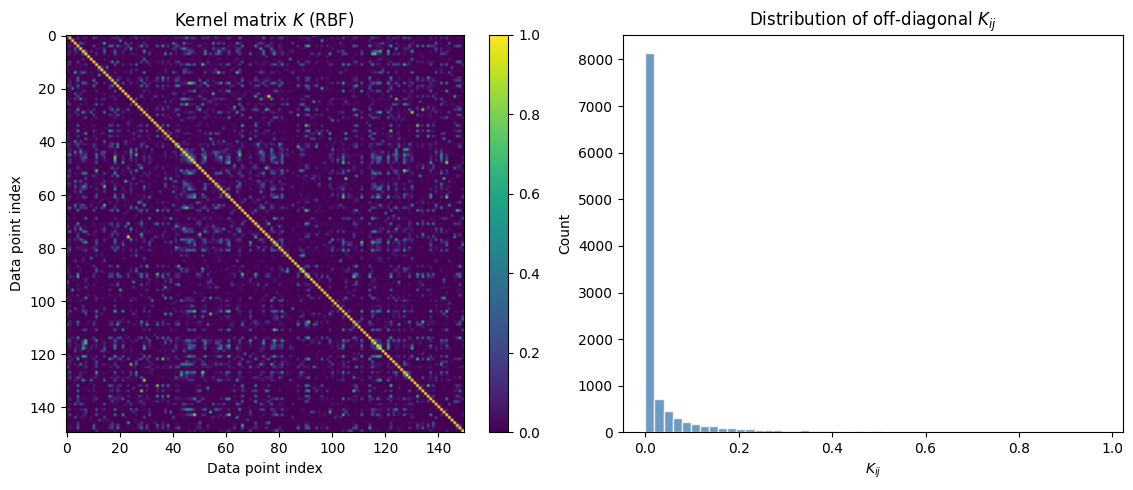

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kernel matrix
im0 = axes[0].imshow(gpc.K, cmap='viridis', aspect='equal')
axes[0].set_title('Kernel matrix $K$ (RBF)')
axes[0].set_xlabel('Data point index')
axes[0].set_ylabel('Data point index')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Histogram of off-diagonal entries
off_diag = gpc.K[np.triu_indices(gpc.N, k=1)]
axes[1].hist(off_diag, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of off-diagonal $K_{ij}$')
axes[1].set_xlabel('$K_{ij}$')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig("../results/GPC/kernel_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Sampling: NUTS vs HMC

We run both Dual-Averaging NUTS and Dual-Averaging HMC on this 150-dimensional posterior with a fully dense prior covariance. Because every parameter is correlated with every other, the leapfrog integrator must compute dense matrix–vector products at every step, a stringent test of numerical stability.

In [6]:
np.random.seed(0)

theta0 = np.random.randn(gpc.d) * 0.1  # small random init near zero
M = 500              # Total iterations
M_adapt = 250        # Warmup / adaptation iterations
delta = 0.65         # Target acceptance rate

results = {}
all_samples = {}
all_stats = {}

for sampler_name, SamplerClass in [("Dual Averaging NUTS", nuts.DualAveragingNUTS),
                                    ("Dual Averaging HMC", hmc.DualAveragingHMC)]:
    print(f"\n{'='*60}")
    print(f"Starting {sampler_name} sampling for GP Classification")

    model = GradCounter(gpc)
    sampler = SamplerClass(L=model.log_p, grad=model.grad)

    if sampler_name == "Dual Averaging HMC":
        samples, stats = sampler.sample(theta0.copy(), delta=delta, lam=1.0, M=M, M_adapt=M_adapt)
    else:
        samples, stats = sampler.sample(theta0.copy(), delta=delta, M=M, M_adapt=M_adapt)

    print(f"Finished {sampler_name}. Output shape: {samples.shape}")
    print(f"Total gradient evaluations: {model.count}")

    valid_samples = samples[M_adapt:]

    # Compute worst-case ESS across all dimensions
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float('inf')
    for dim in range(gpc.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue

        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    ess_per_grad = min_ess / model.count
    results[sampler_name] = {
        'min_ess': min_ess,
        'grad_evals': model.count,
        'ess_per_grad': ess_per_grad,
    }
    all_samples[sampler_name] = samples
    all_stats[sampler_name] = stats

    print(f"Worst-case ESS: {min_ess:.4f}")
    print(f"ESS / gradient: {ess_per_grad:.6f}")


Starting Dual Averaging NUTS sampling for GP Classification
Finished Dual Averaging NUTS. Output shape: (501, 150)
Total gradient evaluations: 24840
Worst-case ESS: 53.0703
ESS / gradient: 0.002136

Starting Dual Averaging HMC sampling for GP Classification
Finished Dual Averaging HMC. Output shape: (501, 150)
Total gradient evaluations: 6388
Worst-case ESS: 9.6943
ESS / gradient: 0.001518


In [ ]:
summary_df = pd.DataFrame(results).T
summary_df.columns = ['Worst-case ESS', 'Gradient Evaluations', 'ESS / Gradient']
print(summary_df.to_string())

                     Worst-case ESS  Gradient Evaluations  ESS / Gradient
Dual Averaging NUTS       53.070329               24840.0        0.002136
Dual Averaging HMC         9.694342                6388.0        0.001518


## Diagnostics

### 1. Step-size adaptation and acceptance statistics

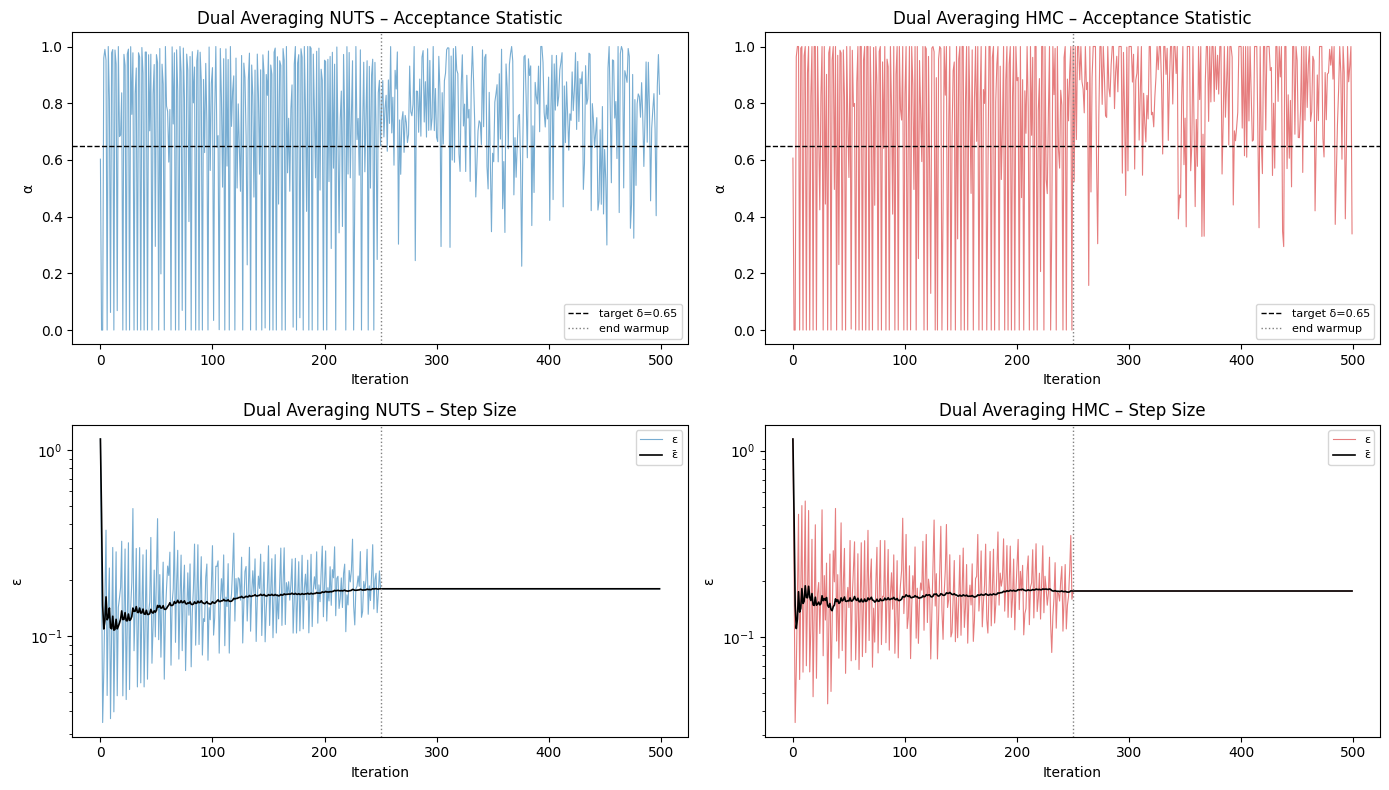

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (name, stats) in enumerate(all_stats.items()):
    color = 'tab:blue' if 'NUTS' in name else 'tab:red'

    # Acceptance statistic
    axes[0, idx].plot(stats['h_stat'], alpha=0.6, color=color, lw=0.8)
    axes[0, idx].axhline(delta, color='black', ls='--', lw=1, label=f'target δ={delta}')
    axes[0, idx].axvline(M_adapt, color='gray', ls=':', lw=1, label='end warmup')
    axes[0, idx].set_title(f'{name} – Acceptance Statistic')
    axes[0, idx].set_xlabel('Iteration')
    axes[0, idx].set_ylabel('α')
    axes[0, idx].legend(fontsize=8)

    # Step size
    axes[1, idx].plot(stats['epsilon'], alpha=0.6, color=color, lw=0.8, label='ε')
    axes[1, idx].plot(stats['epsilon_bar'], color='black', lw=1.2, label='ε̄')
    axes[1, idx].axvline(M_adapt, color='gray', ls=':', lw=1)
    axes[1, idx].set_title(f'{name} – Step Size')
    axes[1, idx].set_xlabel('Iteration')
    axes[1, idx].set_ylabel('ε')
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].set_yscale('log')

plt.tight_layout()
plt.savefig("../results/GPC/adaptation_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()

### 2. Trace plots (selected latent dimensions)

Trace plots for a few representative latent function values $f_i$. Good mixing should show the chain exploring the space without getting stuck. Because of the dense correlations, poor samplers will exhibit strong autocorrelation.

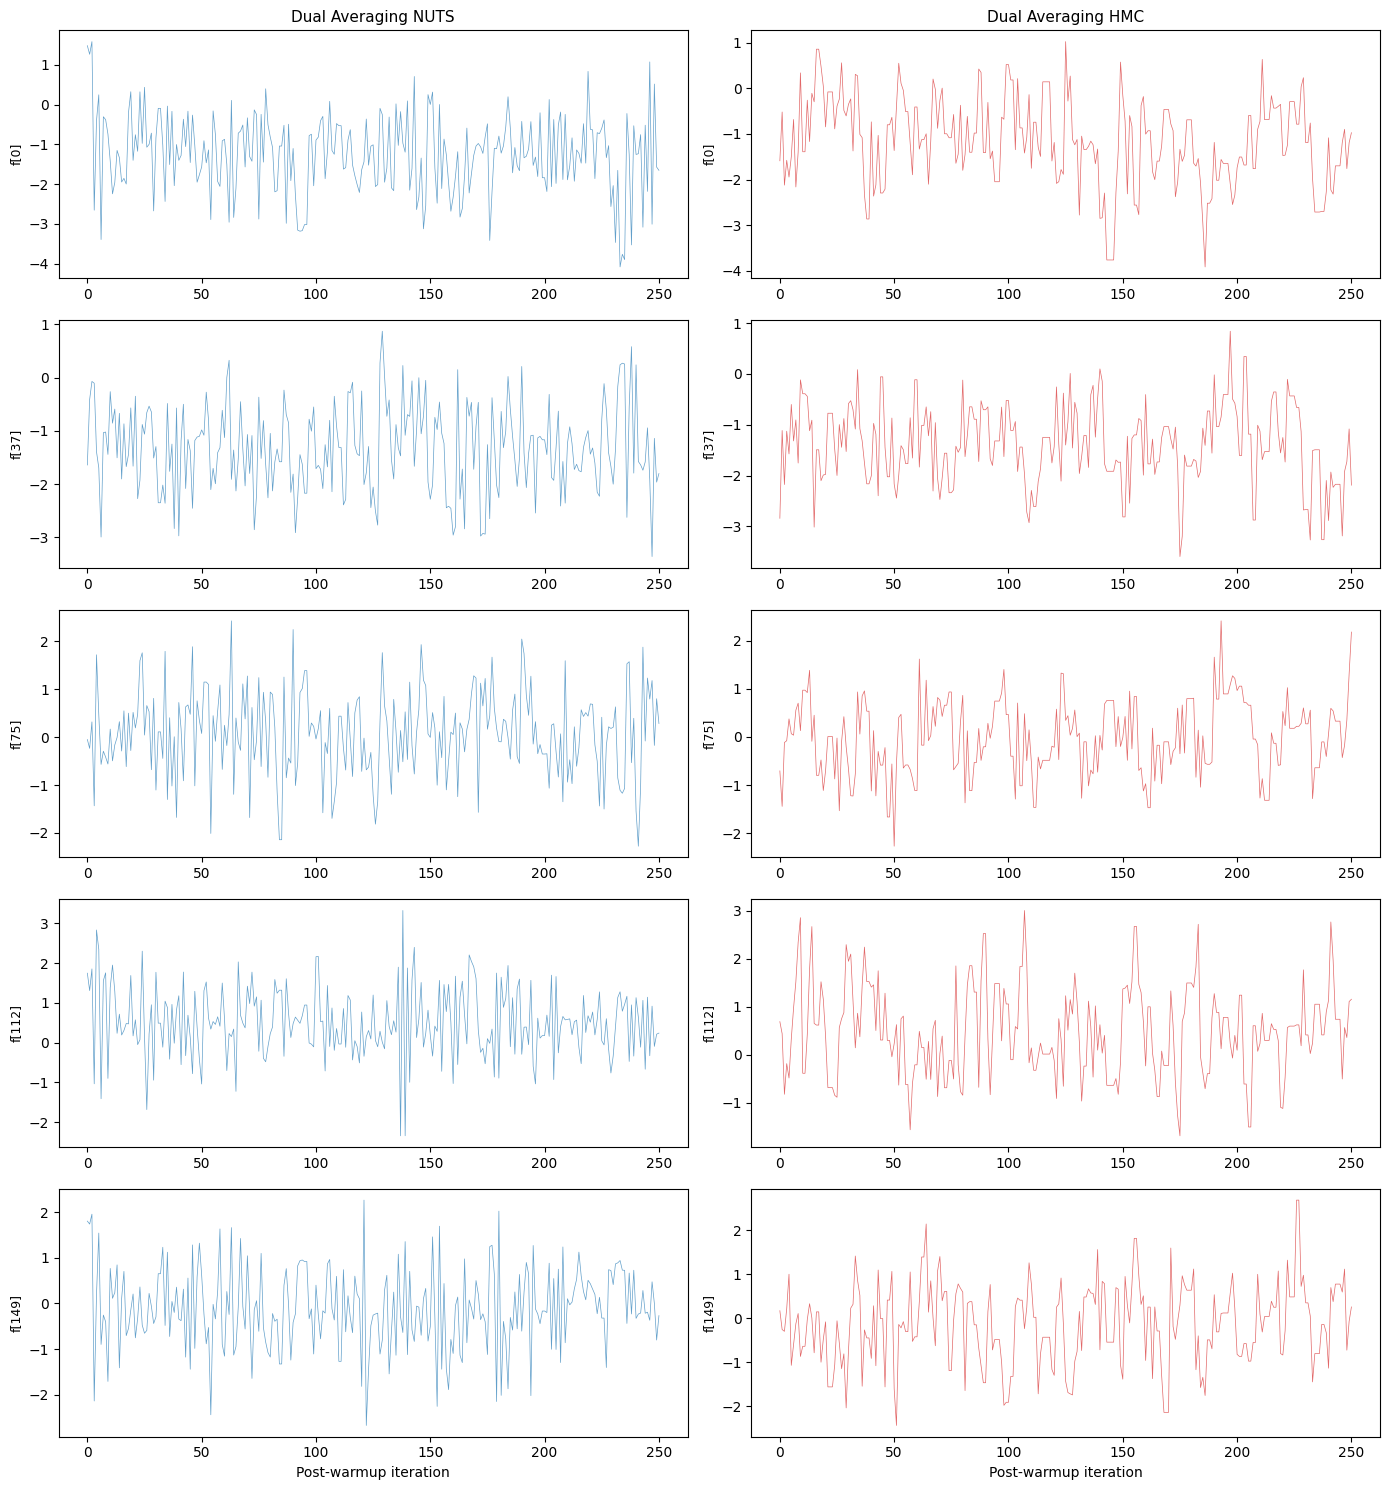

In [9]:
# Select a few dimensions spread across the latent vector
dims_to_plot = [0, N_sub // 4, N_sub // 2, 3 * N_sub // 4, N_sub - 1]
dim_labels = [f'f[{d}]' for d in dims_to_plot]

fig, axes = plt.subplots(len(dims_to_plot), 2, figsize=(14, 3 * len(dims_to_plot)))

for row, (dim, label) in enumerate(zip(dims_to_plot, dim_labels)):
    for col, name in enumerate(all_samples.keys()):
        samples = all_samples[name]
        color = 'tab:blue' if 'NUTS' in name else 'tab:red'
        axes[row, col].plot(samples[M_adapt:, dim], alpha=0.7, lw=0.5, color=color)
        axes[row, col].set_ylabel(label, fontsize=9)
        if row == 0:
            axes[row, col].set_title(name, fontsize=11)
        if row == len(dims_to_plot) - 1:
            axes[row, col].set_xlabel('Post-warmup iteration')

plt.tight_layout()
plt.savefig("../results/GPC/trace_plots.png", dpi=150, bbox_inches='tight')
plt.show()

### 3. Log-posterior over iterations

Monitoring the log-posterior value reached by each sampler. A sampler that handles the dense correlations well should reach and maintain higher log-posterior values.

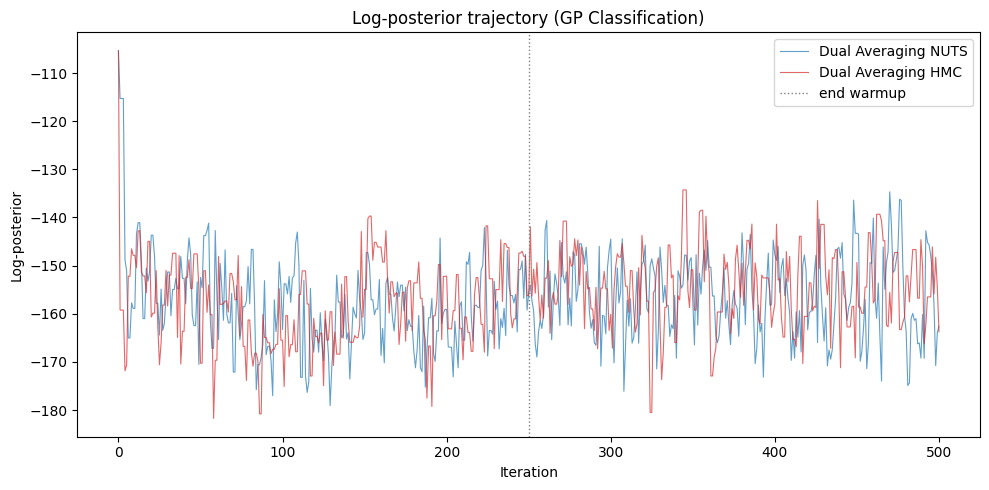

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, samples in all_samples.items():
    color = 'tab:blue' if 'NUTS' in name else 'tab:red'
    log_posts = [gpc.log_p(samples[i]) for i in range(len(samples))]
    ax.plot(log_posts, alpha=0.7, lw=0.8, color=color, label=name)

ax.axvline(M_adapt, color='gray', ls=':', lw=1, label='end warmup')
ax.set_xlabel('Iteration')
ax.set_ylabel('Log-posterior')
ax.set_title('Log-posterior trajectory (GP Classification)')
ax.legend()
plt.tight_layout()
plt.savefig("../results/GPC/log_posterior.png", dpi=150, bbox_inches='tight')
plt.show()

### 4. Trajectory lengths (NUTS adaptive vs HMC fixed)

NUTS automatically selects how many leapfrog steps to take per iteration. With dense correlations, the optimal trajectory length can vary substantially across the posterior.

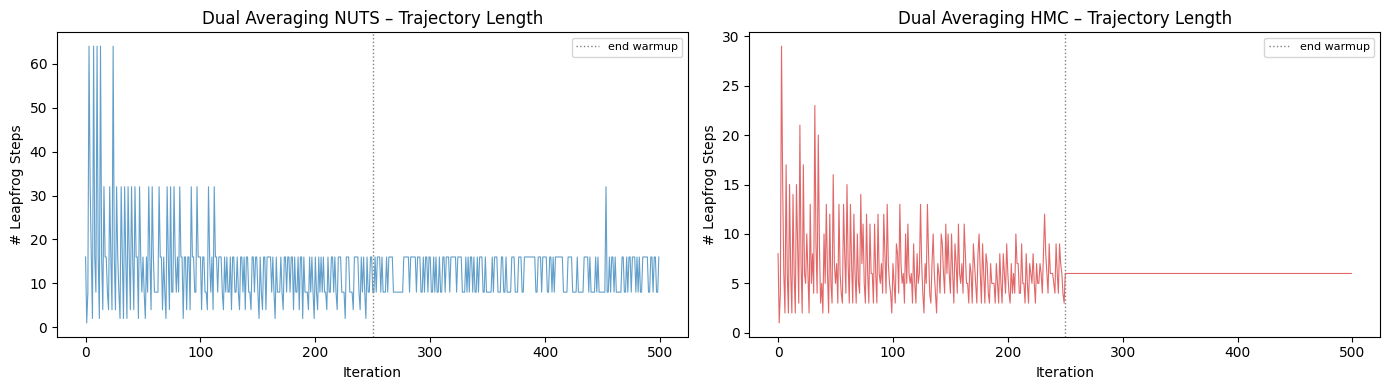

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for idx, (name, stats) in enumerate(all_stats.items()):
    color = 'tab:blue' if 'NUTS' in name else 'tab:red'
    axes[idx].plot(stats['trajectory_length'], alpha=0.7, lw=0.8, color=color)
    axes[idx].set_title(f'{name} – Trajectory Length')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('# Leapfrog Steps')
    axes[idx].axvline(M_adapt, color='gray', ls=':', lw=1, label='end warmup')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/GPC/trajectory_lengths.png", dpi=150, bbox_inches='tight')
plt.show()

### 5. Pairwise latent correlations in posterior samples

Since the GP prior induces dense correlations, we check that the samplers capture them by examining the empirical correlation matrix of the posterior latent samples.

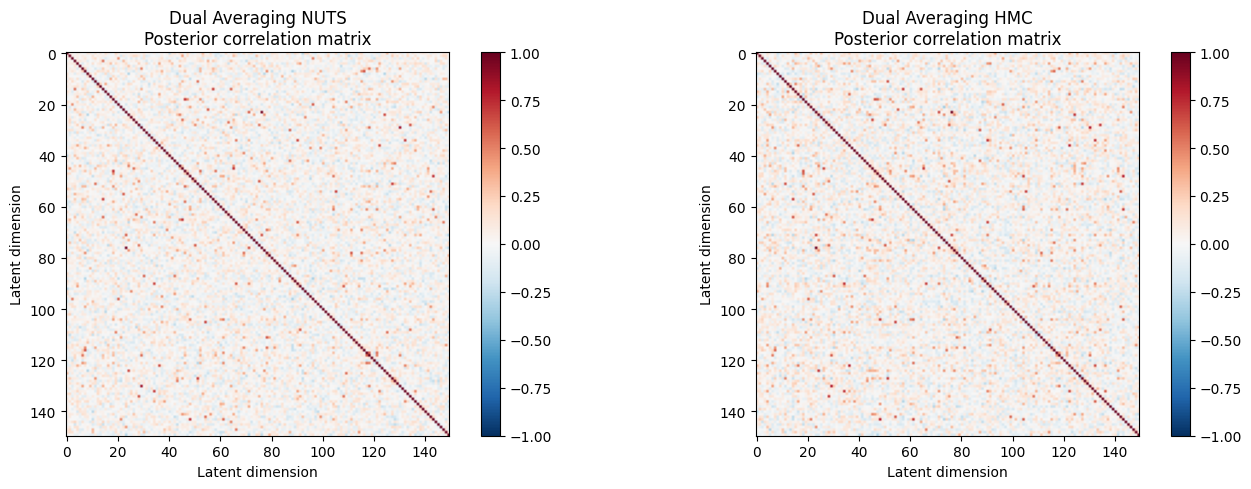

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, samples) in enumerate(all_samples.items()):
    valid = samples[M_adapt:]
    corr = np.corrcoef(valid.T)
    im = axes[idx].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    axes[idx].set_title(f'{name}\nPosterior correlation matrix')
    axes[idx].set_xlabel('Latent dimension')
    axes[idx].set_ylabel('Latent dimension')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.tight_layout()
plt.savefig("../results/GPC/posterior_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

## Predictive Performance

Using the posterior latent samples to make Bayesian predictions on the training set via Bayesian Model Averaging: for each posterior sample $f^{(m)}$, compute $p(y_i = 1 \mid f_i^{(m)}) = \sigma(f_i^{(m)})$ and average across samples.

In [ ]:
from scipy.special import expit as sigmoid

for name, samples in all_samples.items():
    valid = samples[M_adapt:]

    # Bayesian Model Averaging: average predicted probabilities
    probs = np.zeros(gpc.N)
    for i in range(len(valid)):
        probs += sigmoid(valid[i])
    probs /= len(valid)

    # Convert probabilities to labels
    preds = np.where(probs > 0.5, 1, -1)
    accuracy = np.mean(preds == y_sub)

    # Log-loss
    avg_logit = np.zeros(gpc.N)
    for i in range(len(valid)):
        avg_logit += valid[i]
    avg_logit /= len(valid)
    z = -y_sub * avg_logit
    log_loss = np.mean(np.logaddexp(0, z))

    print(f"\n{name}:")
    print(f"  Training accuracy:  {accuracy:.4f}")
    print(f"  Training log-loss:  {log_loss:.4f}")

Dual Averaging NUTS:
  Training accuracy:  0.9400
  Training log-loss:  0.4374

Dual Averaging HMC:
  Training accuracy:  0.9333
  Training log-loss:  0.4372



## NUTS Efficiency across $\delta$

Sweep the target acceptance rate $\delta$ for NUTS and measure ESS per gradient evaluation, following the same protocol as the other notebooks.

In [ ]:
deltas = np.linspace(0.3, 0.9, 7)
results_delta = []

for d_val in deltas:
    print(f"Sampling for delta={d_val:.2f}...")

    model = GradCounter(gpc)
    sampler = nuts.DualAveragingNUTS(L=model.log_p, grad=model.grad)

    theta_init = np.random.randn(gpc.d) * 0.1
    samples, stats = sampler.sample(theta_init, delta=d_val, M=M, M_adapt=M_adapt)

    valid_samples = samples[M_adapt:]
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float('inf')
    for dim in range(gpc.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue
        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    total_grads = model.count
    ess_per_grad = min_ess / total_grads
    results_delta.append((d_val, min_ess, total_grads, ess_per_grad))
    print(f"  delta={d_val:.2f}  |  ESS={min_ess:.4f}  |  Grads={total_grads}  |  ESS/grad={ess_per_grad:.6f}\n")

results_delta_df = pd.DataFrame(results_delta, columns=["Delta", "Worst-case ESS", "Total Gradients", "ESS per Gradient"])
results_delta_df.to_csv("../results/GPC/DANUTS_delta.csv", index=False)
print(results_delta_df.to_string(index=False))

Sampling for δ=0.30...
  δ=0.30  |  ESS=3.9559  |  Grads=8698  |  ESS/grad=0.000455

Sampling for δ=0.40...
  δ=0.40  |  ESS=54.8659  |  Grads=14986  |  ESS/grad=0.003661

Sampling for δ=0.50...
  δ=0.50  |  ESS=48.1727  |  Grads=17736  |  ESS/grad=0.002716

Sampling for δ=0.60...
  δ=0.60  |  ESS=53.8344  |  Grads=21014  |  ESS/grad=0.002562

Sampling for δ=0.70...
  δ=0.70  |  ESS=70.9726  |  Grads=28382  |  ESS/grad=0.002501

Sampling for δ=0.80...
  δ=0.80  |  ESS=56.2812  |  Grads=31528  |  ESS/grad=0.001785

Sampling for δ=0.90...
  δ=0.90  |  ESS=51.7061  |  Grads=32612  |  ESS/grad=0.001585

 Delta  Worst-case ESS  Total Gradients  ESS per Gradient
   0.3        3.955929             8698          0.000455
   0.4       54.865859            14986          0.003661
   0.5       48.172735            17736          0.002716
   0.6       53.834428            21014          0.002562
   0.7       70.972624            28382          0.002501
   0.8       56.281244            31528      

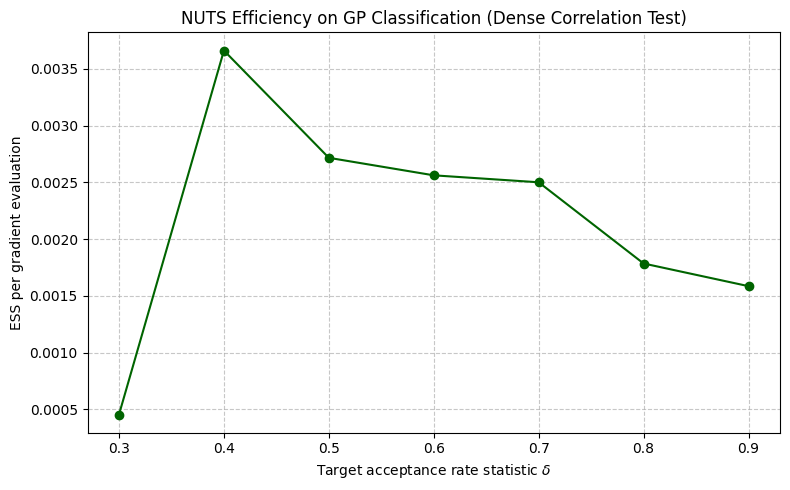

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(results_delta_df["Delta"], results_delta_df["ESS per Gradient"], marker='o', linestyle='-', color='darkgreen')
plt.xlabel('Target acceptance rate statistic $\\delta$')
plt.ylabel('ESS per gradient evaluation')
plt.title('NUTS Efficiency on GP Classification (Dense Correlation Test)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../results/GPC/GPC_efficiency_plot.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

The GP classification model with an RBF kernel produces a fully dense $150 \times 150$ covariance matrix $K$. Every latent function value $f_i$ is correlated with every other $f_j$ — the strength depending on the distance $\|x_i - x_j\|$ in feature space. This forces the leapfrog integrator to propagate gradients through dense matrix–vector products ($K^{-1}f$) at every step.

Key observations:
- NUTS adapts its trajectory length at each iteration, which is critical when the posterior geometry is shaped by dense, heterogeneous correlations. It can take longer trajectories to traverse strongly correlated directions and shorter ones in weakly correlated directions.
- HMC with a fixed trajectory length may overshoot or undershoot depending on the local curvature, leading to either wasted computation or poor exploration.
- The posterior correlation matrices from the samples should reflect the dense structure of the GP prior, confirming that the sampler correctly captures the inter-parameter dependencies.
- The ESS-per-gradient metric quantifies how efficiently each sampler converts computational work into independent posterior samples under dense correlations.
- Dense correlations are a fundamental challenge for MCMC: they concentrate the probability mass on a thin, curved manifold in high-dimensional space, making random-walk proposals extremely inefficient.